In [45]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

#Load DataSet
df=sns.load_dataset("taxis")
print(data)

#Describe,Analyxe DataSet
df.describe(include="object") #Only object columns
df.info
df.shape

#Check Duplicates and Nulls
df.isnull().sum()
df.duplicated().sum()
df.dropna(inplace=True)







    CustomerID  Age  Annual_Income  Gender Region  Spending_Score
0            1   56          97969    Male   West            87.0
1            2   46          35311    Male   East            47.0
2            3   32         113104    Male   West            84.0
3            4   25          83707    Male  North            77.0
4            5   38         115305    Male   West            82.0
5            6   56          58693    Male   East            55.0
6            7   36         101932  Female   East            52.0
7            8   40          55658  Female  South            31.0
8            9   28         114478    Male  North            71.0
9           10   28          48431  Female   West            78.0
10          11   41          32747  Female  South            39.0
11          12   53          89150  Female   West            84.0
12          13   57          95725  Female   West            82.0
13          14   41         114654    Male  South            33.0
14        

<Axes: xlabel='color', ylabel='tip'>

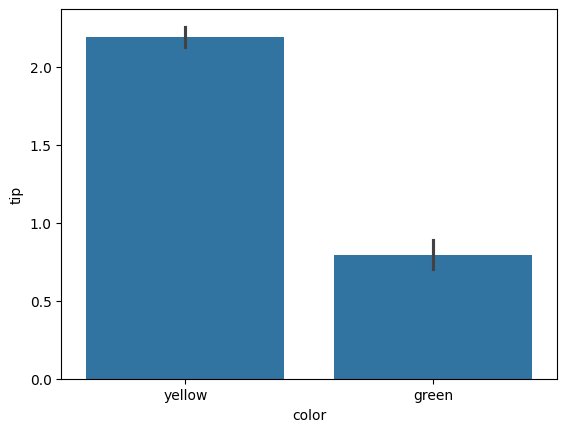

In [21]:
#tip is numerical feature,analyze with color features with categorical
df.color.value_counts()

#Graphical Analysis Of Categorical Data
sns.barplot(x=df.color,y=df.tip,estimator="mean")

<Axes: xlabel='color', ylabel='tip'>

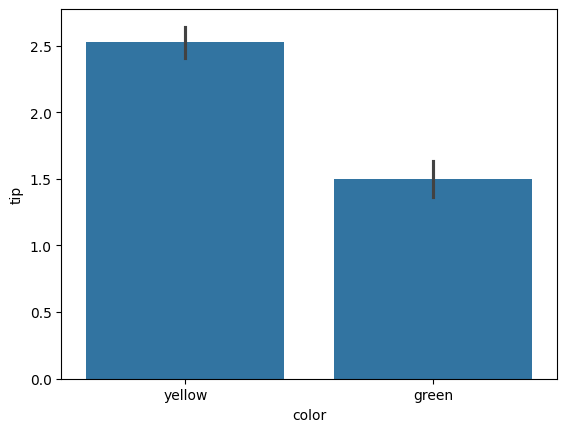

In [22]:
sns.barplot(x=df.color,y=df.tip,estimator="std")

In [37]:
'''Hypothesis:
H0:distribution of tip for yellow=green
H1:distribution of tip for yellow!=green'''

credit_tip=df['tip'][df['payment']=='credit card']
cash_tip=df['tip'][df['payment']=='cash']

#Independent T-Test
from scipy import stats
t_stat,p_val=stats.ttest_ind(credit_tip,cash_tip)
print(t_stat,p_val)

alpha=0.5 #significance level
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

47.5771244729178 0.0
Reject Null Hypothesis


In [36]:
yellow_tip=df[df['payment']=='creditcard']['tip']
green_tip=df[df['payment']=='cash']['tip']

# Independent T-Test
from scipy import stats
t_stat,p_val=stats.ttest_ind(yellow_tip,green_tip)
print(t_stat,p_val)

alpha=0.5 #significance level
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

nan nan
Fail to Reject Null Hypothesis


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


<Axes: xlabel='payment', ylabel='tip'>

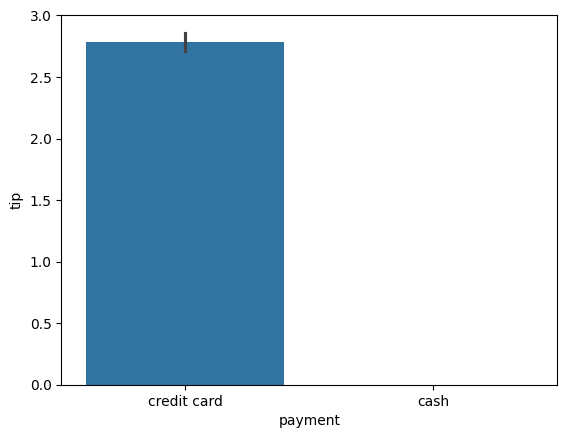

In [38]:
sns.barplot(x=df.payment,y=df.tip,estimator="mean")

<Axes: xlabel='tip', ylabel='Count'>

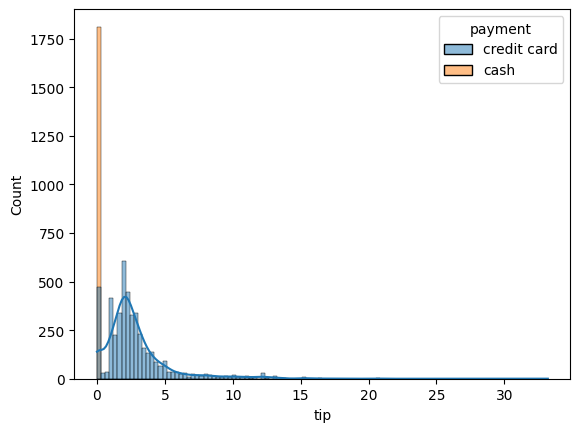

In [41]:
sns.histplot(x=df.tip,hue=df.payment,kde=True)

In [46]:
df.dropna(inplace=True)
df['pickup_borough'].unique()

array(['Manhattan', 'Queens', 'Bronx', 'Brooklyn'], dtype=object)

<Axes: xlabel='pickup_borough', ylabel='count'>

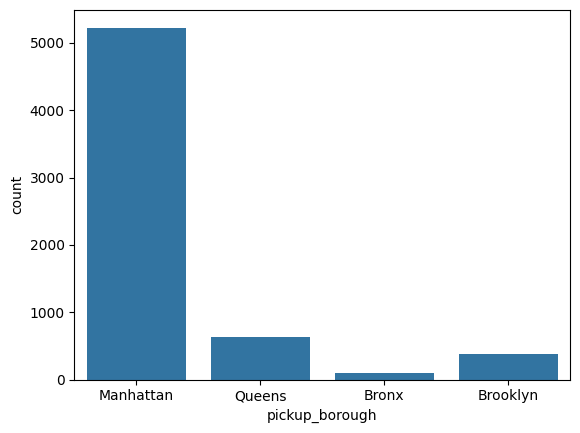

In [49]:
sns.countplot(x=df['pickup_borough'])

<Axes: xlabel='pickup_borough', ylabel='tip'>

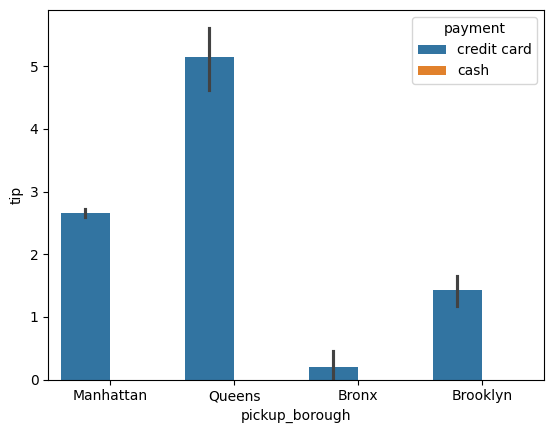

In [51]:
sns.barplot(x=df['pickup_borough'],y=df['tip'],estimator='mean',hue=df['payment'])

In [53]:
df['tip'].groupby(df['pickup_borough']).mean()

,tip
pickup_borough,
Bronx,0.148586
Brooklyn,0.979127
Manhattan,1.945597
Queens,3.066458


<Axes: xlabel='tip', ylabel='Count'>

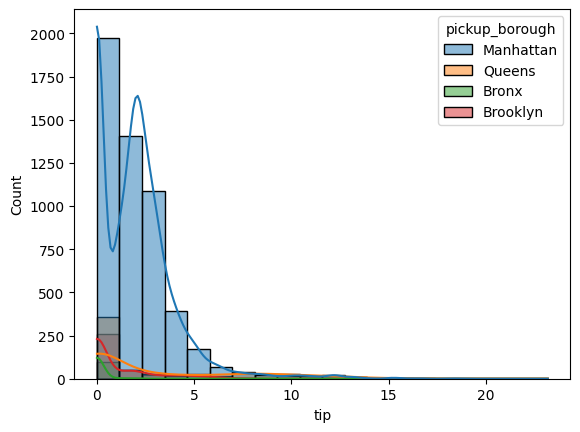

In [54]:
sns.histplot(hue=df['pickup_borough'],x=df['tip'],bins=20,kde=True)

In [55]:
'''
h0:distribution of tip is the same across all pickup_borough categories
h1:distribution of tip is not the same across all pickup_borough categories
atleast one category has a different distribution of tip'''
#ANOVA
manhattan_tip=df['tip'][df['pickup_borough']=='Manhattan']
queens_tip=df['tip'][df['pickup_borough']=='Queens']
brooklyn_tip=df['tip'][df['pickup_borough']=='Brooklyn']
bronx_tip=df['tip'][df['pickup_borough']=='Bronx']
stat,p_val=stats.f_oneway(manhattan_tip,queens_tip,brooklyn_tip,bronx_tip)
alpha=0.05
print(stat,p_val)
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")


91.57933831850573 5.155109332422435e-58
Reject Null Hypothesis


In [57]:
'''h0:mean spending score of group1=mean spending score of group2
h1:mean spending score of group1!=mean spending score of group2'''

from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Perform Tukey HSD
tukey_result=pairwise_tukeyhsd(endog=df.tip,groups=df.pickup_borough,alpha=0.05)

#Display the results
print(tukey_result)
alpha=0.05
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1    group2  meandiff p-adj lower  upper  reject
-------------------------------------------------------
    Bronx  Brooklyn   0.8305 0.008 0.1595 1.5015   True
    Bronx Manhattan    1.797   0.0  1.194    2.4   True
    Bronx    Queens   2.9179   0.0 2.2759 3.5599   True
 Brooklyn Manhattan   0.9665   0.0 0.6499  1.283   True
 Brooklyn    Queens   2.0873   0.0 1.7016 2.4731   True
Manhattan    Queens   1.1209   0.0 0.8716 1.3701   True
-------------------------------------------------------
Reject Null Hypothesis


In [ ]:
sns.countplot(x=df['dropoff_borough'])

In [64]:
'''
h0:distribution of tip is the same across all pickup_borough categories
h1:distribution of tip is not the same across all pickup_borough categories
atleast one category has a different distribution of tip'''
#ANOVA
boroughs=[group['tip'].values for name,group in df.groupby('dropoff_borough')]
stat,p_val=stats.f_oneway(*boroughs)
alpha=0.05
print(stat,p_val)
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")


31.42417796696828 5.87859571331583e-26
Reject Null Hypothesis


In [63]:
'''h0:mean spending score of group1=mean spending score of group2
h1:mean spending score of group1!=mean spending score of group2'''

from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Perform Tukey HSD
tukey_result=pairwise_tukeyhsd(endog=df.tip,groups=df.dropoff_borough,alpha=0.05)

#Display the results
print(tukey_result)
alpha=0.05
p_val=tukey_result.pvalues[0]
print(p_val)
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1      group2    meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
    Bronx      Brooklyn   1.3869    0.0  0.7691  2.0046   True
    Bronx     Manhattan   1.4296    0.0  0.8751  1.9842   True
    Bronx        Queens   1.8873    0.0  1.2742  2.5005   True
    Bronx Staten Island  13.6303    0.0  9.0833 18.1773   True
 Brooklyn     Manhattan   0.0427 0.9952 -0.2571  0.3425  False
 Brooklyn        Queens   0.5004 0.0055  0.1026  0.8983   True
 Brooklyn Staten Island  12.2434    0.0  7.7204 16.7664   True
Manhattan        Queens   0.4577 0.0002  0.1675  0.7479   True
Manhattan Staten Island  12.2007    0.0  7.6859 16.7154   True
   Queens Staten Island   11.743    0.0  7.2206 16.2653   True
--------------------------------------------------------------
9.561382019462883e-09
Reject Null Hypothesis


<Axes: xlabel='dropoff_borough', ylabel='count'>

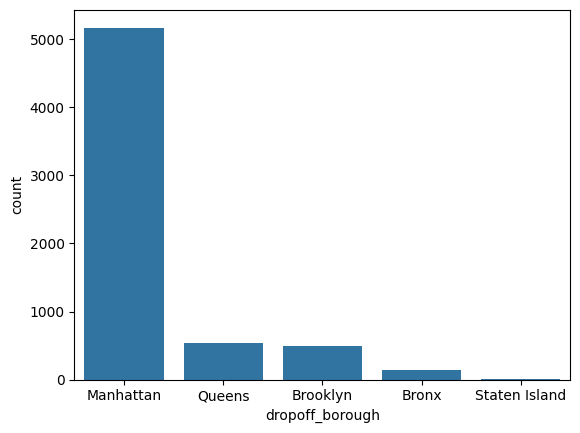

In [61]:
sns.countplot(x=df['dropoff_borough'])

In [65]:
len(df.pickup_zone.unique())
len(df.dropoff_zone.unique())

203

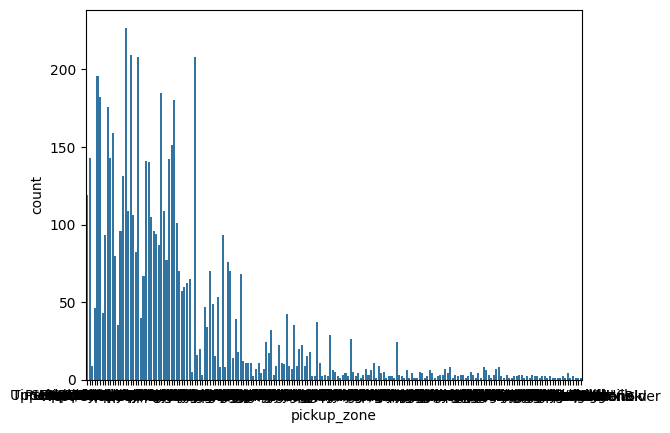

In [66]:
sns.countplot(x=df['pickup_zone'])
plt.show()

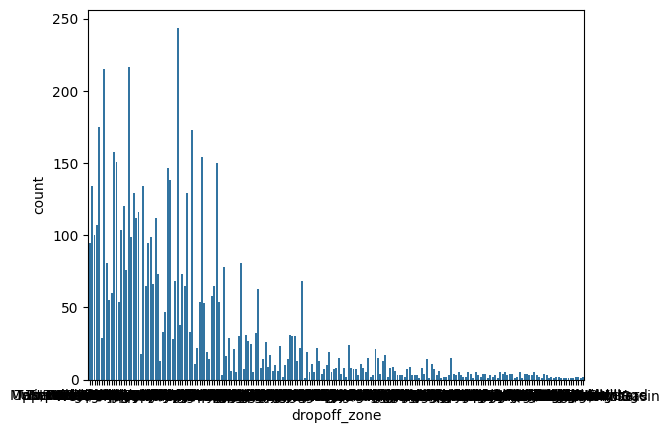

In [67]:
sns.countplot(x=df['dropoff_zone'])
plt.show()

In [69]:
'''for pickup_zone&dropoff_zone'''
pickup_zone=[group['tip'].values for name,group in df.groupby('pickup_zone')]
dropoff_zone=[group['tip'].values for name,group in df.groupby('dropoff_zone')]
stat,p_val=stats.f_oneway(*pickup_zone)
print(stat,p_val)
alpha=0.05
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")


7.563376210961916 7.892434822136223e-169
Reject Null Hypothesis


In [70]:
'''for pickup_zone&dropoff_zone'''
pickup_zone=[group['tip'].values for name,group in df.groupby('pickup_zone')]
dropoff_zone=[group['tip'].values for name,group in df.groupby('dropoff_zone')]
stat,p_val=stats.f_oneway(*dropoff_zone)
print(stat,p_val)
alpha=0.05
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

5.76903467327541 1.3107168403745948e-120
Reject Null Hypothesis


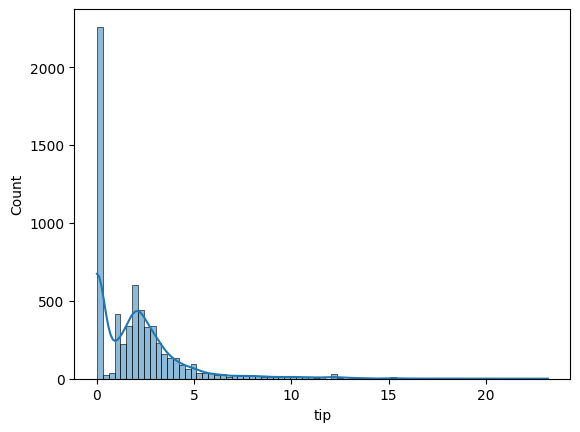

In [71]:
#Univariate analysis for numerical columns
sns.histplot(df['tip'],kde=True)
plt.show()

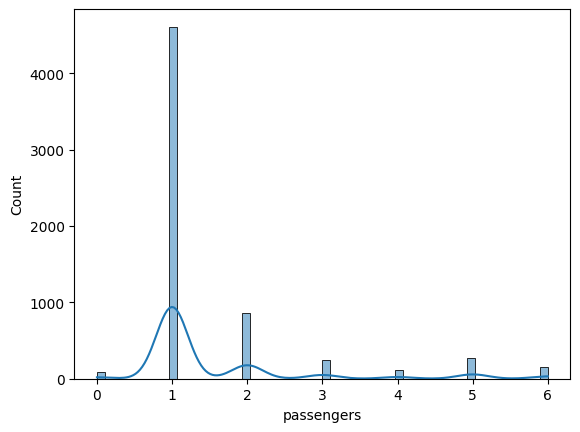

In [72]:
sns.histplot(df['passengers'],kde=True)
plt.show()

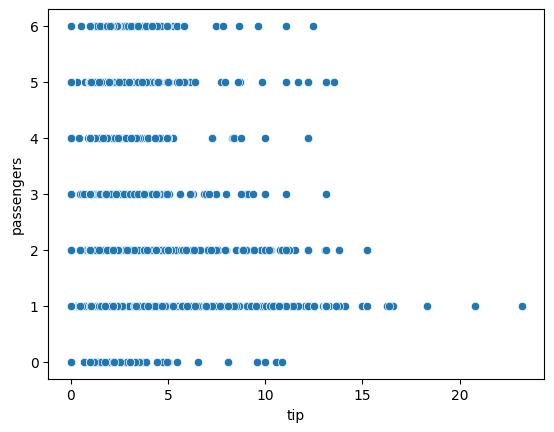

In [73]:
sns.scatterplot(x=df['tip'],y=df['passengers'])
plt.show()

In [74]:
r,p_val=stats.pearsonr(df['tip'],df['passengers'])
print(r,p_val)
alpha=0.05
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

0.017838280361313713 0.15551969503298518
Fail to Reject Null Hypothesis


In [75]:
r,p_val=stats.spearmanr(df['tip'],df['passengers'])
print(r,p_val)
alpha=0.05
if p_val<alpha:
  print("Reject Null Hypothesis")
else:
  print("Fail to Reject Null Hypothesis")

0.027509812818779178 0.028480753176042872
Reject Null Hypothesis
